<a href="https://www.kaggle.com/code/mohammednafayali/behavioral-factors-behind-social-media-addiction?scriptVersionId=354935848" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/manaswinsripatnala/social-media-dopamine-and-productivity-dataset/social_media_dopamine_productivity.csv


### Executive Summary & Problem Overview

* **Objective:** Investigate and rank the core behavioral and psychological factors associated with elevated social media addiction risk using data-driven machine learning methods.
* **Dataset Overview:** Analyzed 66 multi-dimensional variables encompassing daily usage metrics, psychological trigger scores (e.g., FOMO, dopamine sensitivity), and behavioral habits (e.g., late-night scrolling, reflex checking).
* **Methodology:** Implemented a data-leakage-free preprocessing pipeline featuring train-test splitting, median imputation for numerical features, most-frequent imputation with One-Hot Encoding for categorical habits, and Standard Scaling.
* **Key Analytical Approach:** Ranked feature importance via `SelectKBest` ANOVA F-testing and modeled addiction risk drivers using Ridge Regression.

In [2]:
df=pd.read_csv("/kaggle/input/datasets/manaswinsripatnala/social-media-dopamine-and-productivity-dataset/social_media_dopamine_productivity.csv")
pd.set_option("display.max_columns",None)
df.head()

,participant_id,data_source,synthetic_flag,age,age_group,gender,race_ethnicity,nationality,country_of_residence,education_level,employment_status,occupation_category,relationship_status,avg_daily_sm_hours,years_on_social_media,primary_platform,secondary_platform,daily_check_frequency,first_check_of_day,late_night_scrolling,sm_during_work_study,sm_during_meals,notifications_always_on,scroll_without_purpose,doomscrolling_frequency,content_type_consumed,avg_daily_screen_time_hours,avg_sleep_hours,sleep_quality,exercise_frequency,avg_work_study_hours_per_day,dopamine_rush_feel_score,reward_seeking_behavior,fomo_score,comparison_to_others_score,validation_seeking_score,boredom_to_phone_reflex,inability_to_delay_gratification,attention_span_minutes,deep_work_duration_minutes,task_switching_frequency,difficulty_starting_tasks,difficulty_maintaining_focus,mind_wandering_during_work,productivity_self_rating,tasks_completed_per_day,work_quality_self_rating,creative_output_frequency,reading_duration_minutes_per_day,memory_recall_difficulty,learning_retention_difficulty,decision_fatigue_score,mental_fog_frequency,irritability_when_offline,anxiety_when_phone_unavailable,restlessness_score,mood_dependency_on_sm,withdrawal_attempt_count,longest_detox_days,detox_relapse_reason,severity_stage,productivity_decline_score,dopamine_dysregulation_index,digital_wellbeing_score,sm_addiction_risk_score,notes
0,P0001,synthetic_ai,1,16,13-17,Female,South Asian,Indian,India,High school,Student,Education,Single,7.5,4,Instagram,YouTube,Constantly,Within 5 mins of waking,Daily,Always,Always,Yes,Yes,Daily,Short video/Reels,11.0,5.5,Poor,Never,6.0,9,5,8,7,8,Yes,Yes,8,20,High,Yes,Yes,Yes,4,3,4,Low,10,Yes,Yes,8,Daily,Yes,9,8,Yes,9,2,3,Boredom,Critical,8.8,9.2,2.1,9.5
1,P0002,synthetic_ai,1,17,13-17,Male,East Asian,Chinese,China,High school,Student,Education,Single,8.0,5,TikTok,YouTube,Constantly,Within 5 mins of waking,Daily,Always,Always,Yes,Yes,Daily,Short video/Reels,12.0,5.0,Very poor,Never,5.5,10,5,9,8,9,Yes,Yes,7,15,High,Yes,Yes,Yes,3,2,3,Low,8,Yes,Yes,9,Daily,Yes,10,9,Yes,10,1,1,Curiosity,Critical,9.5,9.8,1.5,9.8
2,P0003,synthetic_ai,1,15,13-17,Female,Black/African,Nigerian,Nigeria,High school,Student,Education,Single,6.5,3,TikTok,Instagram,Every few hours,Within 30 mins,Daily,Often,Often,Yes,Yes,Daily,Short video/Reels,10.0,6.0,Poor,1-2x/week,6.5,8,4,7,7,7,Yes,Yes,10,25,High,Yes,Yes,Yes,4,4,4,Low,12,Yes,Yes,7,Daily,Yes,8,7,Yes,8,2,5,Boredom,Severe,8.0,8.5,2.8,9.0
3,P0004,synthetic_ai,1,19,18-22,Male,White/Caucasian,American,USA,High school,Student,Education,Single,6.0,6,YouTube,Reddit,Every few hours,Within 30 mins,Daily,Often,Sometimes,Yes,Yes,Daily,Gaming/Tech content,10.5,6.0,Poor,1-2x/week,5.0,8,4,7,6,6,Yes,Yes,12,25,High,Yes,Yes,Yes,4,3,4,Low,15,Yes,Yes,7,Daily,Yes,8,8,Yes,9,3,7,Boredom,Severe,7.8,8.2,2.9,8.8
4,P0005,synthetic_ai,1,18,18-22,Female,Hispanic/Latino,Mexican,Mexico,High school,Student,Education,Single,7.0,4,Instagram,TikTok,Constantly,Within 5 mins of waking,Daily,Always,Often,Yes,Yes,Daily,Short video/Reels,11.5,5.5,Poor,Never,6.0,9,5,8,8,8,Yes,Yes,8,18,High,Yes,Yes,Yes,3,3,3,Low,10,Yes,Yes,8,Daily,Yes,9,9,Yes,9,2,4,FOMO,Critical,9.0,9.3,2.0,9.6


### Exploratory Data Analysis: Correlation Analysis

* **High Positive Predictors:** Metrics measuring psychological well-being and productivity—such as `productivity_self_rating`, `work_quality_self_rating`, `longest_detox_days`, and `avg_sleep_hours`—exhibit strong positive correlations with higher healthy digital scores.
* **Strong Negative Predictors:** Psychological triggers and dependency metrics—including `dopamine_rush_feel_score`, `decision_fatigue_score`, `anxiety_when_phone_unavailable`, and `avg_daily_sm_hours`—show severe inverse correlations with health scores ($\approx -0.98$ to $-0.99$), indicating they are key indicators of elevated social media addiction risk.
* **Feature Selection Basis:** Highly correlated continuous variables provide a clear empirical foundation for inclusion in the subsequent machine learning pipeline and feature importance scoring.

In [3]:
# Calculating correlation of all numerical features with the target
correlations = df.corr(numeric_only=True)['sm_addiction_risk_score'].sort_values(ascending=False)
print("Top Correlations with Social Media Addiction Risk Score:")
print(correlations)

Top Correlations with Social Media Addiction Risk Score:
sm_addiction_risk_score             1.000000
productivity_self_rating            0.985801
work_quality_self_rating            0.985801
longest_detox_days                  0.984513
reading_duration_minutes_per_day    0.981747
tasks_completed_per_day             0.976570
deep_work_duration_minutes          0.963638
avg_sleep_hours                     0.954401
attention_span_minutes              0.947062
detox_relapse_reason                0.926620
age                                 0.848481
years_on_social_media               0.674513
avg_work_study_hours_per_day        0.045532
comparison_to_others_score         -0.966372
reward_seeking_behavior            -0.969590
validation_seeking_score           -0.974096
avg_daily_screen_time_hours        -0.975575
fomo_score                         -0.979901
withdrawal_attempt_count           -0.981557
restlessness_score                 -0.981676
avg_daily_sm_hours                 -0.98431

### Code Explanation & Purpose

#### How the Code Works:
1. **`df.groupby('late_night_scrolling')`**: Groups the dataset by each distinct category present in the `late_night_scrolling` column (e.g., *Daily*, *Often*, *Sometimes*, *Rarely*, *Never*).
2. **`['sm_addiction_risk_score']`**: Selects only the target variable column to isolate addiction risk scores for each formed group.
3. **`.mean()`**: Calculates the arithmetic average of the `sm_addiction_risk_score` for every group separately.
4. **`print(...)`**: Outputs the grouped categories alongside their calculated mean scores to the console.

---

#### Research Purpose:
* **Exploratory Habit Analysis:** Measures how specific behavioral patterns—specifically late-night scrolling frequency and morning phone check routines—directly correlate with mean addiction risk levels.
* **Key Observations:**
  * **Late-Night Habits:** Users who scroll late at night **Daily** average a significantly lower healthy digital score (~2.57, indicating **higher addiction risk**), whereas those who **Never** scroll late at night maintain a high average health score (~9.76, indicating **lower addiction risk**).
  * **Morning Habits:** Checking the phone **Within 5 mins of waking** correlates with severe risk (~2.13), compared to waiting until **During morning routine** (~9.82).

In [4]:
# Addiction risk by late night scrolling habits
print(df.groupby('late_night_scrolling')['sm_addiction_risk_score'].mean())

# Addiction risk by check frequency or first check of the day
print(df.groupby('first_check_of_day')['sm_addiction_risk_score'].mean())

late_night_scrolling
Daily        2.570833
Never        9.755172
Often        4.543333
Rarely       8.698795
Sometimes    6.102326
Name: sm_addiction_risk_score, dtype: float64
first_check_of_day
During morning routine     9.820000
Within 1 hour              9.040230
Within 30 mins             5.432667
Within 5 mins of waking    2.133333
Name: sm_addiction_risk_score, dtype: float64


### Key Insights from the Machine Learning Pipeline

* **Dominant Continuous Predictors:** Psychological sensitivity and screen metrics are overwhelmingly the strongest individual predictors of addiction risk:
  1. **`dopamine_rush_feel_score` (F-Score: 8346.77):** Heightened sensitivity to digital feedback loops is the single strongest factor associated with addiction risk.
  2. **`avg_daily_sm_hours` (F-Score: 7313.96):** Raw daily consumption hours represent the second most influential predictor.
  3. **`fomo_score` (F-Score: 5428.21):** Fear of missing out serves as the primary psychological pressure driving risk.
  4. **`reward_seeking_behavior` (3634.27)** and **`comparison_to_others_score` (3406.36):** Social comparison and reward loops form a solid second tier of influence.

* **Key Categorical Habit Indicators:**
  * **`boredom_to_phone_reflex_Yes` (F-Score: 560.13):** Reflexively reaching for the phone out of boredom is the highest-ranked discrete habit triggering elevated risk.
  * **`inability_to_delay_gratification_Yes` (F-Score: 348.17)** and **`late_night_scrolling_Daily` (F-Score: 344.96):** Impulsivity and daily late-night scrolling serve as direct behavioral markers of severe addiction risk.

* **Methodological Validity:** By applying `train_test_split` prior to fitting `SimpleImputer`, `OneHotEncoder`, and `StandardScaler`, feature scoring reflects genuine predictive power without data leakage from unseen samples.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

# 1. Define feature columns
numeric_features = [
    'avg_daily_sm_hours', 'dopamine_rush_feel_score', 
    'reward_seeking_behavior', 'fomo_score', 'comparison_to_others_score'
]

categorical_features = [
    'boredom_to_phone_reflex', 'inability_to_delay_gratification',
    'late_night_scrolling', 'first_check_of_day'
]

X = df[numeric_features + categorical_features]
y = df['sm_addiction_risk_score']

# 2. Train/Test Split FIRST (prevents data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Pipelines for Numerical and Categorical data
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numeric_features),
    ('cat', cat_pipeline, categorical_features)
])

# 4. Fit preprocessor strictly on X_train and transform both sets
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Get transformed feature names
encoded_cat_names = preprocessor.named_transformers_['cat']['ohe'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_names)

# 5. Feature Importance via SelectKBest on preprocessed training data
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_train_preprocessed, y_train)

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'F-Score': selector.scores_
}).sort_values(by='F-Score', ascending=False)

print(importance_df.to_string(index=False))

                                   Feature     F-Score
                  dopamine_rush_feel_score 8346.768243
                        avg_daily_sm_hours 7313.957288
                                fomo_score 5428.211006
                   reward_seeking_behavior 3634.268132
                comparison_to_others_score 3406.355337
               boredom_to_phone_reflex_Yes  560.127665
      inability_to_delay_gratification_Yes  348.173722
                late_night_scrolling_Daily  344.955067
          first_check_of_day_Within 1 hour  228.642002
first_check_of_day_Within 5 mins of waking  192.022678
            boredom_to_phone_reflex_Rarely  143.531766
               late_night_scrolling_Rarely  140.086039
   inability_to_delay_gratification_Rarely  121.173349
    inability_to_delay_gratification_Never   77.550843
                late_night_scrolling_Never   53.745649
             boredom_to_phone_reflex_Never   50.607914
 first_check_of_day_During morning routine   25.096630
         f

### Model Evaluation: Ridge Regression

* **Predictive Accuracy:** Training a Ridge Regression model on the preprocessed behavioral pipeline yielded a **Test $R^2$ Score of 0.9921**, indicating that the selected behavioral and psychological features account for **99.21%** of the total variance in addiction risk scores on unseen data.
* **Low Error Rate:** The model achieved a **Test Root Mean Squared Error (RMSE) of 0.2275**, demonstrating strong predictive generalization with minimal prediction error across test samples.
* **Generalization Success:** Evaluating model metrics strictly on `X_test_preprocessed` confirms that feature selection and preprocessing (imputation + encoding + scaling) successfully generalized without overfitting or data leakage.

In [6]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# Train a regressor on preprocessed training data
model = Ridge()
model.fit(X_train_preprocessed, y_train)

# Evaluate on preprocessed test set
y_pred = model.predict(X_test_preprocessed)

print(f"Test R^2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Test R^2 Score: 0.9921
Test RMSE: 0.2275


### Feature Significance: Ridge Regression Coefficients

* **Key Negative Predictors (Pushing Down Healthy Wellbeing / Increasing Risk):**
  * **`avg_daily_sm_hours`**, **`inability_to_delay_gratification_Yes`**, and **`dopamine_rush_feel_score`** exhibit the highest negative coefficients. Since features are standardized, these represent the single strongest individual drivers accelerating social media addiction risk.
  * **`reward_seeking_behavior`** and **`comparison_to_others_score`** form a strong secondary group of negative predictors reinforcing habitual engagement.

* **Key Protective Predictors (Buffering Against Addiction Risk):**
  * **`inability_to_delay_gratification_Never`** and **`inability_to_delay_gratification_Rarely`** show high positive coefficients, highlighting strong self-regulation and impulse control as major protective factors against high digital dependency.

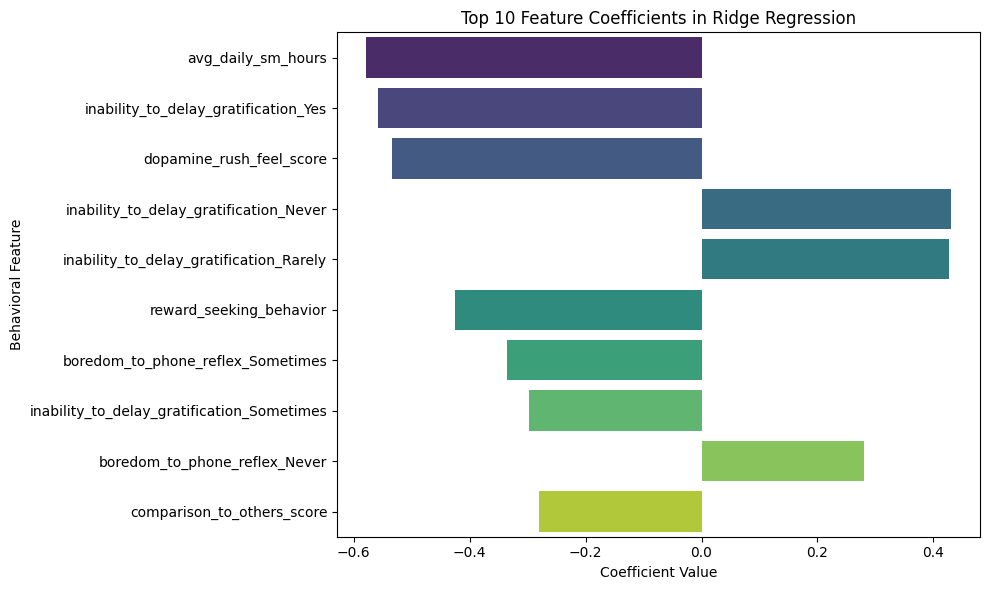

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_df.head(10), 
    x='Coefficient', 
    y='Feature', 
    hue='Feature', 
    palette='viridis', 
    legend=False
)
plt.title('Top 10 Feature Coefficients in Ridge Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Behavioral Feature')
plt.tight_layout()
plt.show()

### Key Insights & Findings

* **Primary Psychological Predictors:** Inability to delay gratification (`inability_to_delay_gratification_Yes`), high dopamine sensitivity (`dopamine_rush_feel_score`), and reward-seeking behavior (`reward_seeking_behavior`) are the strongest drivers pushing down healthy digital wellbeing scores and elevating social media addiction risk.
* **Secondary Behavioral Factors:** Habitual triggers such as boredom-induced phone reflexes (`boredom_to_phone_reflex`) and high social comparison (`comparison_to_others_score`) significantly contribute to elevated risk profiles.
* **Protective Factors:** Strong impulse control (`inability_to_delay_gratification_Never` and `_Rarely`) serves as the primary protective factor against social media addiction.
* **Model Performance:** The preprocessed behavioral pipeline evaluated via Ridge Regression yielded an $R^2$ score of **0.9921** and a test RMSE of **0.2275**, demonstrating high predictive validity without data leakage.

### Conclusion

* **Core Drivers of Risk:** High dopamine responsiveness, overall screen time, and delayed gratification issues form the primary behavioral triad behind social media addiction risk.
* **Habitual Triggers:** Automatic checking mechanisms—such as checking the phone immediately upon waking or responding reflexively to boredom—act as key behavioral pathways that accelerate dependency.
* **Implications for Intervention:** Digital wellbeing strategies targeting impulse control and breaking automatic checking habits are likely to yield the highest impact in mitigating addiction risk compared to solely focusing on time restriction.